# Visualize Awinda: Model ID vs OpenSim ID

Interactive plots for cached awinda processing results from `process_awinda.ipynb`.

- **Cache**: `analysis/cache/process_awinda.npz`
- **Sync**: Awinda vs Vicon IK angle xcorr (from `process_awinda.ipynb`); 15 s post-sync trim on ID metrics
- **IK QC**: synced Vicon vs Awinda IK — RMSE/R² per trial, bad trials flagged
- **ID QC**: Model ID vs OpenSim — flagged trials marked as ID-only bad vs ID+IK bad
- **Views**: sync diagnostics, per-trial ID/IK explorer, bad-trial review
- **Paper outputs**: tables & figures (last cell)

Run `process_awinda.ipynb` first if the cache is missing or stale.


In [1]:
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore', message='.*NumPy.*')

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
CACHE_PATH = PROJECT_ROOT / 'analysis' / 'cache' / 'process_awinda.npz'

CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
DEFAULT_PREVIEW_FRAMES = 500
DEFAULT_ANKLE_THRESHOLD = 0.8

print(f'Cache: {CACHE_PATH}')


Cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz


In [2]:
def _trial_key_to_prefix(trial_key: str) -> str:
    return trial_key.replace('::', '__')


def load_processed_awinda_cache(path=CACHE_PATH):
    data = np.load(str(path), allow_pickle=True)
    channels = [str(c) for c in data['channels']]
    if 'ankle_moment_neg_peak_threshold_nmpkg' in data.files:
        ankle_threshold = float(data['ankle_moment_neg_peak_threshold_nmpkg'].item())
    elif 'knee_moment_peak_threshold_nmpkg' in data.files:
        ankle_threshold = float(data['knee_moment_peak_threshold_nmpkg'].item())
    else:
        ankle_threshold = DEFAULT_ANKLE_THRESHOLD
    preview_frames = int(data['preview_frames'].item()) if 'preview_frames' in data.files else DEFAULT_PREVIEW_FRAMES
    sync_method = str(data['sync_method'].item()) if 'sync_method' in data.files else 'ankle_moment_peak'

    trial_data = {}
    for trial_key in data['trial_keys']:
        key = str(trial_key)
        p = _trial_key_to_prefix(key)
        meta = data[f'{p}__meta']
        rmse = data[f'{p}__rmse_nmpkg']
        r2 = data[f'{p}__r2_nmpkg']
        metrics = [
            {'channel': channels[c], 'rmse_nmpkg': float(rmse[c]), 'r2_nmpkg': float(r2[c])}
            for c in range(len(channels))
        ]

        if sync_method == 'angle_xcorr' or len(meta) == 7:
            xcorr_score = float(meta[5])
            lag_clipped = bool(meta[6])
            pred_peak_idx, id_peak_idx = -1, -1
        else:
            xcorr_score = np.nan
            pred_peak_idx = int(meta[5])
            id_peak_idx = int(meta[6])
            lag_clipped = bool(meta[7])

        entry = {
            'subject': str(meta[0]),
            'condition': str(meta[1]),
            'mass_kg': float(meta[2]),
            't': data[f'{p}__t'],
            'pred_nmpkg': data[f'{p}__pred_nmpkg'],
            'id_nmpkg': data[f'{p}__id_nmpkg'],
            'metrics': metrics,
            'lag_samples': int(meta[3]),
            'lag_seconds': float(meta[4]),
            'sync_method': sync_method,
            'xcorr_score': xcorr_score,
            'pred_peak_idx': pred_peak_idx,
            'id_peak_idx': id_peak_idx,
            'lag_clipped': lag_clipped,
        }
        if f'{p}__sync_pred_pre' in data.files:
            pred_ankle_key = f'{p}__sync_pred_ankle' if f'{p}__sync_pred_ankle' in data.files else f'{p}__sync_pred_knee'
            id_ankle_key = f'{p}__sync_id_ankle' if f'{p}__sync_id_ankle' in data.files else f'{p}__sync_id_knee'
            entry['sync_debug'] = {
                'fs_hz': float(data[f'{p}__sync_fs_hz'].item()),
                'n_sync': int(data[f'{p}__sync_n'].item()),
                't_id': data[f'{p}__sync_t_id'],
                't_imu': data[f'{p}__sync_t_imu'],
                'pred_pre': data[f'{p}__sync_pred_pre'],
                'id_pre': data[f'{p}__sync_id_pre'],
                'pred_ankle': data[pred_ankle_key],
                'id_ankle': data[id_ankle_key],
                'pred_peak_idx': entry['pred_peak_idx'],
                'id_peak_idx': entry['id_peak_idx'],
                'lag': entry['lag_samples'],
                'sync_method': sync_method,
                'xcorr_score': entry['xcorr_score'],
            }
            if f'{p}__sync_awinda_hip_deg' in data.files:
                entry['sync_debug']['awinda_hip_deg'] = data[f'{p}__sync_awinda_hip_deg']
                entry['sync_debug']['vicon_hip_deg'] = data[f'{p}__sync_vicon_hip_deg']
        trial_data[key] = entry

    summary_df = (
        pd.read_json(io.StringIO(str(data['summary_df'].item())), orient='split')
        if 'summary_df' in data.files else pd.DataFrame()
    )
    detail_df = (
        pd.read_json(io.StringIO(str(data['detail_df'].item())), orient='split')
        if 'detail_df' in data.files else pd.DataFrame()
    )
    print(f'Loaded {len(trial_data)} trials from {path} (sync={sync_method})')
    return trial_data, summary_df, detail_df, ankle_threshold, preview_frames


TRIAL_DATA, summary_df, detail_df, ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG, PREVIEW_FRAMES = load_processed_awinda_cache()

if not detail_df.empty:
    print('\nPer-joint mean across trials:')
    display(detail_df.groupby('channel')[['rmse_nmpkg', 'r2_nmpkg']].mean())


Loaded 40 trials from /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz (sync=angle_xcorr)

Per-joint mean across trials:


,rmse_nmpkg,r2_nmpkg
channel,,
ankle_angle_l,0.174504,0.912621
ankle_angle_r,0.170462,0.913197
hip_flexion_l,0.194894,0.772688
hip_flexion_r,0.212742,0.742013
knee_angle_l,0.139450,0.775387
knee_angle_r,0.140591,0.781829


In [3]:
import pickle
import sys
from scipy.signal import butter, sosfiltfilt

sys.path.insert(0, str(PROJECT_ROOT))
from dataset import IK_DOF_NAMES

PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'VQF'
DEFAULT_TRANSIENT_TRIM_SEC = 15.0
ANGLE_CUTOFF_HZ = 6.0
FILTER_ORDER = 4

IK_MIN_R2 = 0.7
IK_MAX_RMSE_DEG = 15.0  # sagittal IK RMSE in degrees (moment QC uses 0.2 N·m/kg)

IK_CHANNEL_IDX = [IK_DOF_NAMES.index(c) for c in CHANNELS]


def _parse_opensim_table(path: Path) -> pd.DataFrame:
    with open(path) as f:
        header_end = next(i for i, line in enumerate(f) if line.strip().lower() == 'endheader')
    return pd.read_csv(path, sep=r'\s+', skiprows=header_end + 1).set_index('time')


def _butter_lpf(x, fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=FILTER_ORDER):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * fs_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(order, cutoff_hz / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, x)


def _lpf_mc(X, fs_hz):
    return np.column_stack([_butter_lpf(X[:, c], fs_hz) for c in range(X.shape[1])])


def _condition_to_pkl_stem(condition: str) -> str:
    cond, speed = condition.split('_', 1)
    return f'{speed}_{cond.lower()}'


def _build_awinda_ik_rad(imu_dict: dict) -> np.ndarray:
    n = len(next(iter(imu_dict.values())))
    pos_deg = np.zeros((n, len(IK_DOF_NAMES)), dtype=np.float64)
    key_map = {
        'hip_flexion_r': 'hip_flexion_r', 'knee_angle_r': 'knee_flexion_r', 'ankle_angle_r': 'ankle_flexion_r',
        'hip_flexion_l': 'hip_flexion_l', 'knee_angle_l': 'knee_flexion_l', 'ankle_angle_l': 'ankle_flexion_l',
    }
    sign_map = {'knee_angle_r': -1.0, 'knee_angle_l': -1.0}
    for ik_name, pkl_name in key_map.items():
        idx = IK_DOF_NAMES.index(ik_name)
        pos_deg[:, idx] = sign_map.get(ik_name, 1.0) * np.asarray(imu_dict[pkl_name], dtype=np.float64)
    return np.deg2rad(pos_deg)


def _build_vicon_ik_rad(ik_df: pd.DataFrame) -> np.ndarray:
    pos_deg = np.full((len(ik_df), len(IK_DOF_NAMES)), np.nan)
    for j, name in enumerate(IK_DOF_NAMES):
        if name in ik_df.columns:
            pos_deg[:, j] = ik_df[name].to_numpy(dtype=np.float64)
    return np.deg2rad(pos_deg)


def _rmse_r2_deg(y_pred, y_ref):
    m = np.isfinite(y_pred) & np.isfinite(y_ref)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_ref[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    r2 = float(np.corrcoef(y_pred[m], y_ref[m])[0, 1] ** 2)
    return rmse, r2


_cache_meta = np.load(str(CACHE_PATH), allow_pickle=True)
TRANSIENT_TRIM_SEC = (
    float(_cache_meta['transient_trim_sec'].item())
    if 'transient_trim_sec' in _cache_meta.files else DEFAULT_TRANSIENT_TRIM_SEC
)

ik_detail_rows = []
ik_summary_rows = []
ik_errors = []
IK_TRIAL_DATA = {}

for trial_key, d in sorted(TRIAL_DATA.items()):
    subject, cond = d['subject'], d['condition']
    lag = int(d['lag_samples'])
    try:
        pkl_path = IMU_IK_ROOT / subject / 'ik' / IMU_IK_METHOD / f'{_condition_to_pkl_stem(cond)}.pkl'
        vicon_path = PROCESSED_ROOT / subject / 'awinda' / 'ik' / f'{cond}_ik.mot'
        if not pkl_path.exists():
            raise FileNotFoundError(f'Missing Awinda IK pkl: {pkl_path}')
        if not vicon_path.exists():
            raise FileNotFoundError(f'Missing Vicon IK mot: {vicon_path}')

        awinda_rad = _build_awinda_ik_rad(pickle.load(open(pkl_path, 'rb')))
        vicon_df = _parse_opensim_table(vicon_path)
        t_vicon = vicon_df.index.to_numpy(dtype=np.float64)
        vicon_rad = _build_vicon_ik_rad(vicon_df)
        awinda_6 = awinda_rad[:, IK_CHANNEL_IDX]
        vicon_6 = vicon_rad[:, IK_CHANNEL_IDX]

        fs_hz = float(d['sync_debug']['fs_hz']) if 'sync_debug' in d else 100.0
        trim_n = int(round(TRANSIENT_TRIM_SEC * fs_hz))
        start_awinda, start_vicon = max(lag, 0), max(-lag, 0)
        n_sync = min(len(awinda_6) - start_awinda, len(vicon_6) - start_vicon)
        if n_sync <= trim_n:
            raise RuntimeError(f'Not enough samples after {TRANSIENT_TRIM_SEC}s trim: {n_sync}')

        awinda_sync = _lpf_mc(awinda_6[start_awinda:start_awinda + n_sync], fs_hz)
        vicon_sync = _lpf_mc(vicon_6[start_vicon:start_vicon + n_sync], fs_hz)
        awinda_eval = np.rad2deg(awinda_sync[trim_n:])
        vicon_eval = np.rad2deg(vicon_sync[trim_n:])
        t_eval = t_vicon[start_vicon + trim_n:start_vicon + n_sync]

        metrics = []
        for c, channel in enumerate(CHANNELS):
            rmse, r2 = _rmse_r2_deg(awinda_eval[:, c], vicon_eval[:, c])
            metrics.append({'channel': channel, 'rmse_deg': rmse, 'r2': r2})
            ik_detail_rows.append({
                'trial': trial_key, 'subject': subject, 'condition': cond,
                'channel': channel, 'rmse_deg': rmse, 'r2': r2,
            })

        mean_rmse = float(np.nanmean([m['rmse_deg'] for m in metrics]))
        mean_r2 = float(np.nanmean([m['r2'] for m in metrics]))
        IK_TRIAL_DATA[trial_key] = {
            'subject': subject,
            'condition': cond,
            't': t_eval,
            'awinda_deg': awinda_eval,
            'vicon_deg': vicon_eval,
            'metrics': metrics,
        }
        ik_summary_rows.append({
            'trial': trial_key,
            'subject': subject,
            'condition': cond,
            'n': len(awinda_eval),
            'mean_rmse_deg': mean_rmse,
            'mean_r2': mean_r2,
            'lag_samples': lag,
        })
    except Exception as exc:
        ik_errors.append(f'{trial_key}: {exc}')

ik_summary_df = pd.DataFrame(ik_summary_rows)
ik_detail_df = pd.DataFrame(ik_detail_rows)

if ik_errors:
    print('IK comparison warnings:')
    for msg in ik_errors:
        print(f'  [WARN] {msg}')

if ik_summary_df.empty:
    raise RuntimeError('No IK comparisons computed.')

ik_flagged = ik_summary_df[
    (ik_summary_df['mean_r2'] < IK_MIN_R2) | (ik_summary_df['mean_rmse_deg'] > IK_MAX_RMSE_DEG)
].copy()
ik_flagged['fail_r2'] = ik_flagged['mean_r2'] < IK_MIN_R2
ik_flagged['fail_rmse'] = ik_flagged['mean_rmse_deg'] > IK_MAX_RMSE_DEG
IK_BAD_TRIALS = set(ik_flagged['trial'])

print(
    f'Synced Vicon IK vs Awinda IK ({TRANSIENT_TRIM_SEC:.0f}s post-sync trim, 6 Hz zero-phase LPF)\n'
    f'  trials compared: {len(ik_summary_df)}\n'
    f'  QC: mean R² < {IK_MIN_R2} or mean RMSE > {IK_MAX_RMSE_DEG} deg\n'
    f'  flagged: {len(ik_flagged)} / {len(ik_summary_df)}'
)

if ik_flagged.empty:
    print('\nNo IK trials flagged.')
else:
    print('\nFlagged IK trials by subject:')
    for subject in sorted(ik_flagged['subject'].unique()):
        sub = ik_flagged[ik_flagged['subject'] == subject].sort_values('condition')
        parts = []
        for _, row in sub.iterrows():
            reasons = []
            if row['fail_r2']:
                reasons.append(f"R²={row['mean_r2']:.3f}")
            if row['fail_rmse']:
                reasons.append(f"RMSE={row['mean_rmse_deg']:.2f}°")
            parts.append(f"{row['condition']} ({', '.join(reasons)})")
        print(f'  {subject}: {", ".join(parts)}')

print('\nPer-joint mean across trials (IK vs Vicon):')
display(ik_detail_df.groupby('channel')[['rmse_deg', 'r2']].mean())

display(
    ik_summary_df.sort_values(['subject', 'condition'])[
        ['subject', 'condition', 'mean_rmse_deg', 'mean_r2', 'n', 'lag_samples']
    ].reset_index(drop=True)
)

if not ik_flagged.empty:
    print('\nFlagged trials:')
    display(
        ik_flagged.sort_values(['subject', 'condition'])[
            ['subject', 'condition', 'mean_rmse_deg', 'mean_r2', 'n', 'fail_r2', 'fail_rmse']
        ].reset_index(drop=True)
    )

Synced Vicon IK vs Awinda IK (15s post-sync trim, 6 Hz zero-phase LPF)
  trials compared: 40
  QC: mean R² < 0.7 or mean RMSE > 15.0 deg
  flagged: 1 / 40

Flagged IK trials by subject:
  AB05_Maria: LG_0p8mps (R²=0.396, RMSE=154.71°)

Per-joint mean across trials (IK vs Vicon):


,rmse_deg,r2
channel,,
ankle_angle_l,7.352331,0.794089
ankle_angle_r,28.981971,0.786328
hip_flexion_l,6.345436,0.959065
hip_flexion_r,6.617051,0.958234
knee_angle_l,8.661448,0.977984
knee_angle_r,8.070827,0.961329


,subject,condition,mean_rmse_deg,mean_r2,n,lag_samples
0,AB01_Jinwoo,LG_0p8mps,12.744020,0.918633,6500,711
1,AB01_Jinwoo,LG_1p2mps,13.011173,0.923547,6500,722
2,AB01_Jinwoo,LG_1p6mps,12.636867,0.921925,6500,1300
3,AB01_Jinwoo,RA_0p8mps,11.680574,0.982222,6500,873
4,AB01_Jinwoo,RD_0p8mps,13.327129,0.875544,6500,746
5,AB02_Oscar,LG_0p8mps,10.413839,0.904871,6500,1240
6,AB02_Oscar,LG_1p2mps,10.002949,0.937695,6500,288
7,AB02_Oscar,LG_1p6mps,9.192861,0.936450,6500,259
8,AB02_Oscar,RA_0p8mps,7.589258,0.954005,6500,295
9,AB02_Oscar,RD_0p8mps,9.851908,0.874641,6500,759



Flagged trials:


,subject,condition,mean_rmse_deg,mean_r2,n,fail_r2,fail_rmse
0,AB05_Maria,LG_0p8mps,154.714855,0.396027,6500,True,True


In [4]:
if not TRIAL_DATA:
    raise RuntimeError('No trials loaded. Run process_awinda.ipynb first.')
if 'IK_TRIAL_DATA' not in globals() or not IK_TRIAL_DATA:
    raise RuntimeError('Run the IK comparison cell first.')

names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']

# --- ID QC (same thresholds as process_awinda.ipynb) ---
ID_MIN_R2 = 0.7
ID_MAX_RMSE = 0.2

if summary_df.empty:
    id_summary = pd.DataFrame([
        {
            'trial': k,
            'subject': d['subject'],
            'condition': d['condition'],
            'mean_rmse': float(np.nanmean([m['rmse_nmpkg'] for m in d['metrics']])),
            'mean_r2': float(np.nanmean([m['r2_nmpkg'] for m in d['metrics']])),
        }
        for k, d in TRIAL_DATA.items()
    ])
else:
    id_summary = summary_df.copy()
    id_summary[['subject', 'condition']] = id_summary['trial'].str.split('::', n=1, expand=True)

id_flagged = id_summary[
    (id_summary['mean_r2'] < ID_MIN_R2) | (id_summary['mean_rmse'] > ID_MAX_RMSE)
].copy()
id_flagged['fail_r2'] = id_flagged['mean_r2'] < ID_MIN_R2
id_flagged['fail_rmse'] = id_flagged['mean_rmse'] > ID_MAX_RMSE
ID_BAD_TRIALS = set(id_flagged['trial'])

id_flagged['ik_also_bad'] = id_flagged['trial'].isin(IK_BAD_TRIALS)
id_flagged['bad_category'] = np.where(
    id_flagged['ik_also_bad'],
    'ID + IK bad',
    'ID only (IK OK)',
)

both_bad = ID_BAD_TRIALS & IK_BAD_TRIALS
id_only_bad = ID_BAD_TRIALS - IK_BAD_TRIALS
ik_only_bad = IK_BAD_TRIALS - ID_BAD_TRIALS

print(
    f'ID QC: mean R² < {ID_MIN_R2} or mean RMSE > {ID_MAX_RMSE} N·m/kg\n'
    f'  flagged: {len(id_flagged)} / {len(id_summary)}'
)
print(
    f'  ID+IK bad: {len(both_bad)} | ID only: {len(id_only_bad)} | IK only: {len(ik_only_bad)}'
)

if id_flagged.empty:
    print('\nNo ID trials flagged.')
else:
    print('\nFlagged ID trials by subject (IK status noted):')
    for subject in sorted(id_flagged['subject'].unique()):
        sub = id_flagged[id_flagged['subject'] == subject].sort_values('condition')
        parts = []
        for _, row in sub.iterrows():
            reasons = []
            if row['fail_r2']:
                reasons.append(f"R²={row['mean_r2']:.3f}")
            if row['fail_rmse']:
                reasons.append(f"RMSE={row['mean_rmse']:.3f}")
            parts.append(f"{row['condition']} ({', '.join(reasons)}) [{row['bad_category']}]")
        print(f'  {subject}: {", ".join(parts)}')

    display(
        id_flagged.sort_values(['subject', 'condition'])[
            ['subject', 'condition', 'mean_rmse', 'mean_r2', 'bad_category', 'fail_r2', 'fail_rmse']
        ].reset_index(drop=True)
    )


def _trial_label(trial_key: str) -> str:
    tags = []
    if trial_key in ID_BAD_TRIALS:
        tags.append('ID')
    if trial_key in IK_BAD_TRIALS:
        tags.append('IK')
    if tags:
        return f'{trial_key} [{"+".join(tags)} bad]'
    return trial_key


_trial_options = [( _trial_label(k), k) for k in sorted(TRIAL_DATA)]
trial_dd = widgets.Dropdown(options=_trial_options, description='Trial:')
unit_dd = widgets.Dropdown(options=['N·m/kg', 'N·m'], value='N·m/kg', description='ID unit:')
time_slider = widgets.FloatRangeSlider(description='Time (s):', continuous_update=False, layout=widgets.Layout(width='700px'))
sync_out = widgets.Output()
out = widgets.Output()
ik_out = widgets.Output()


def _trial_time_rel(trial_key):
    t_id = np.asarray(TRIAL_DATA[trial_key]['t'], dtype=np.float64)
    t_rel = t_id - t_id[0]
    if trial_key in IK_TRIAL_DATA:
        t_ik = np.asarray(IK_TRIAL_DATA[trial_key]['t'], dtype=np.float64)
        t_ik_rel = t_ik - t_ik[0]
        n = min(len(t_rel), len(t_ik_rel))
        t_rel = t_rel[:n]
    return t_rel


def _set_slider(trial_key):
    t_rel = _trial_time_rel(trial_key)
    tmin, tmax = float(t_rel[0]), float(t_rel[-1])
    step = max((tmax - tmin) / 500, 1e-3)
    with time_slider.hold_sync():
        time_slider.min = tmin
        time_slider.max = tmax
        time_slider.step = step
        time_slider.value = (tmin, tmax)


def _qc_badge(trial_key: str) -> str:
    if trial_key in both_bad:
        return ' | QC: ID+IK bad'
    if trial_key in id_only_bad:
        return ' | QC: ID bad, IK OK'
    if trial_key in ik_only_bad:
        return ' | QC: IK bad, ID OK'
    return ''


def _draw_sync(trial_key):
    d = TRIAL_DATA[trial_key]
    if 'sync_debug' not in d:
        with sync_out:
            sync_out.clear_output(wait=True)
            print('No sync preview in cache — re-run process_awinda.ipynb to regenerate.')
        return

    sd = d['sync_debug']
    fs_hz = sd['fs_hz']
    preview_n = min(PREVIEW_FRAMES, sd['n_sync'], len(d['pred_nmpkg']), len(d['id_nmpkg']))
    preview_t = np.arange(preview_n) / fs_hz

    pred_full = sd['pred_pre']
    id_full = sd['id_pre']
    n_pre_pred = min(PREVIEW_FRAMES, len(pred_full))
    n_pre_id = min(PREVIEW_FRAMES, len(id_full))
    t_pre_pred = sd['t_imu'][:n_pre_pred]
    t_pre_id = sd['t_id'][:n_pre_id] - sd['t_id'][0]

    pred_nmpkg_f = d['pred_nmpkg']
    id_nmpkg_f = d['id_nmpkg']

    fig, axs = plt.subplots(6, 2, figsize=(14, 16), sharex='col')
    for c, name in enumerate(names):
        ax_pre, ax_post = axs[c]
        ax_pre.plot(t_pre_id, id_full[:n_pre_id, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax_pre.plot(t_pre_pred, pred_full[:n_pre_pred, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax_pre.set_ylabel('N·m/kg')
        ax_pre.set_title(f'{name} | pre-sync')
        ax_pre.set_xlim(0, PREVIEW_FRAMES / fs_hz)
        ax_pre.axhline(0, color='gray', lw=0.5, ls=':')
        if c == 0:
            ax_pre.legend(loc='upper right', fontsize=8)

        ax_post.plot(preview_t, id_nmpkg_f[:preview_n, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax_post.plot(preview_t, pred_nmpkg_f[:preview_n, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax_post.set_title(f'{name} | post-sync')
        ax_post.set_xlim(0, PREVIEW_FRAMES / fs_hz)
        ax_post.axhline(0, color='gray', lw=0.5, ls=':')
        if c == 0:
            ax_post.legend(loc='upper right', fontsize=8)

    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time since sync (s)')
    fig.suptitle(
        f"{trial_key}{_qc_badge(trial_key)} | lag={sd['lag']:+d} samples ({sd['lag'] / fs_hz:+.3f} s) | first {PREVIEW_FRAMES} frames",
        fontsize=12,
    )
    fig.tight_layout()

    fig2, ax = plt.subplots(figsize=(12, 4))
    if sd.get('sync_method') == 'angle_xcorr' and 'awinda_hip_deg' in sd:
        t_imu = sd['t_imu'] - sd['t_imu'][0]
        t_id_rel = sd['t_id'] - sd['t_id'][0]
        ax.plot(t_id_rel, sd['vicon_hip_deg'], label='Vicon hip R', color='#1e88e5', lw=1.8)
        ax.plot(t_imu, sd['awinda_hip_deg'], label='Awinda hip R', color='#43a047', lw=1.4)
        lag = int(sd['lag'])
        sp = max(lag, 0)
        n_shift = max(0, min(len(t_id_rel), len(sd['awinda_hip_deg']) - sp))
        if n_shift > 0:
            ax.plot(
                t_id_rel[:n_shift], sd['awinda_hip_deg'][sp:sp + n_shift],
                label=f'Awinda shifted ({lag / fs_hz:+.2f}s)', color='#1e88e5', lw=1.2, ls='--', alpha=0.85,
            )
        else:
            ax.axvline(lag / fs_hz, color='#1e88e5', ls='--', alpha=0.6,
                       label=f'lag={lag / fs_hz:+.2f}s (beyond {PREVIEW_FRAMES / fs_hz:.0f}s preview)')
        ax.set_ylabel('Hip flexion R (deg)')
        ax.set_title(f"{trial_key} | angle xcorr sync (score={sd.get('xcorr_score', np.nan):.3f})")
    else:
        t_imu = sd['t_imu'] - sd['t_imu'][0]
        t_id_rel = sd['t_id'] - sd['t_id'][0]
        ax.plot(t_imu, sd['pred_ankle'], label='Model (Awinda IK)', color='#e53935', lw=1.4)
        ax.plot(t_id_rel, sd['id_ankle'], label='OpenSim ID', color='#1e88e5', lw=1.8)
        if sd.get('pred_peak_idx', -1) >= 0:
            ax.axvline(sd['pred_peak_idx'] / fs_hz, color='#e53935', ls='--', alpha=0.6)
            ax.axvline(sd['id_peak_idx'] / fs_hz, color='#1e88e5', ls='--', alpha=0.6)
        ax.set_ylabel('Ankle moment R (N·m/kg)')
        ax.set_title(f'{trial_key} | sync reference signals')
    x_end = PREVIEW_FRAMES / fs_hz
    if sd.get('sync_method') == 'angle_xcorr':
        x_end = max(x_end, abs(int(sd.get('lag', 0))) / fs_hz + 2.0)
    ax.set_xlim(0, x_end)
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right', fontsize=8)
    fig2.tight_layout()

    with sync_out:
        sync_out.clear_output(wait=True)
        plt.show()
        plt.show()


def _draw_id(trial_key, unit, t_window):
    d = TRIAL_DATA[trial_key]
    t = _trial_time_rel(trial_key)
    scale = 1.0 if unit == 'N·m/kg' else d['mass_kg']
    ylab = unit
    y_pred = np.asarray(d['pred_nmpkg'], dtype=np.float64) * scale
    y_id = np.asarray(d['id_nmpkg'], dtype=np.float64) * scale
    n = min(len(t), len(y_pred), len(y_id))
    t, y_pred, y_id = t[:n], y_pred[:n], y_id[:n]
    t0, t1 = t_window

    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for c, ax in enumerate(axs.reshape(-1)):
        m = d['metrics'][c]
        ax.plot(t, y_id[:, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax.plot(t, y_pred[:, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{names[c]} | RMSE={m['rmse_nmpkg']*scale:.3f}, R²={m['r2_nmpkg']:.3f}")
        ax.set_xlim(t0, t1)
        ax.set_ylabel(ylab)
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        if c == 0:
            ax.legend()
    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time (s)')
    fig.suptitle(
        f"{trial_key}{_qc_badge(trial_key)} | Model ID vs OpenSim ID | lag={d['lag_samples']:+d} samples",
        fontsize=12,
    )
    fig.tight_layout()
    with out:
        out.clear_output(wait=True)
        plt.show()


def _draw_ik(trial_key, t_window):
    if trial_key not in IK_TRIAL_DATA:
        with ik_out:
            ik_out.clear_output(wait=True)
            print(f'No IK data for {trial_key}.')
        return

    d = IK_TRIAL_DATA[trial_key]
    y_awinda = np.asarray(d['awinda_deg'], dtype=np.float64)
    y_vicon = np.asarray(d['vicon_deg'], dtype=np.float64)
    n = min(len(y_awinda), len(y_vicon))
    t = np.asarray(d['t'][:n], dtype=np.float64)
    t = t - t[0]
    y_awinda, y_vicon = y_awinda[:n], y_vicon[:n]
    t0, t1 = t_window

    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for c, ax in enumerate(axs.reshape(-1)):
        m = d['metrics'][c]
        ax.plot(t, y_vicon[:, c], label='Vicon IK', color='#1e88e5', lw=1.8)
        ax.plot(t, y_awinda[:, c], label='Awinda IK', color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{names[c]} | RMSE={m['rmse_deg']:.2f}°, R²={m['r2']:.3f}")
        ax.set_xlim(t0, t1)
        ax.set_ylabel('Angle (deg)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        if c == 0:
            ax.legend()
    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time (s)')
    fig.suptitle(
        f"{trial_key}{_qc_badge(trial_key)} | Awinda IK vs Vicon IK (synced + {TRANSIENT_TRIM_SEC:.0f}s trim)",
        fontsize=12,
    )
    fig.tight_layout()
    with ik_out:
        ik_out.clear_output(wait=True)
        plt.show()


def _redraw(*_):
    trial_key = trial_dd.value
    _draw_sync(trial_key)
    _draw_id(trial_key, unit_dd.value, time_slider.value)
    _draw_ik(trial_key, time_slider.value)


def _on_trial(change):
    _set_slider(change['new'])
    _redraw()

trial_dd.observe(_on_trial, names='value')
unit_dd.observe(_redraw, names='value')
time_slider.observe(_redraw, names='value')
_set_slider(trial_dd.value)
display(widgets.VBox([
    widgets.HBox([trial_dd, unit_dd]),
    time_slider,
    widgets.HTML('<b>Sync diagnostics</b>'),
    sync_out,
    widgets.HTML('<b>Synced ID explorer (Model vs OpenSim)</b>'),
    out,
    widgets.HTML('<b>Synced IK explorer (Awinda vs Vicon)</b>'),
    ik_out,
]))
_redraw()


ID QC: mean R² < 0.7 or mean RMSE > 0.2 N·m/kg
  flagged: 8 / 40
  ID+IK bad: 1 | ID only: 7 | IK only: 0

Flagged ID trials by subject (IK status noted):
  AB01_Jinwoo: RD_0p8mps (RMSE=0.206) [ID only (IK OK)]
  AB02_Oscar: LG_0p8mps (R²=0.445, RMSE=0.323) [ID only (IK OK)], LG_1p2mps (R²=0.664, RMSE=0.303) [ID only (IK OK)], LG_1p6mps (RMSE=0.325) [ID only (IK OK)], RA_0p8mps (R²=0.683, RMSE=0.278) [ID only (IK OK)], RD_0p8mps (R²=0.625, RMSE=0.363) [ID only (IK OK)]
  AB05_Maria: LG_0p8mps (R²=0.196, RMSE=0.429) [ID + IK bad]
  AB08_Seokhyun: RA_0p8mps (RMSE=0.212) [ID only (IK OK)]


,subject,condition,mean_rmse,mean_r2,bad_category,fail_r2,fail_rmse
0,AB01_Jinwoo,RD_0p8mps,0.206252,0.765883,ID only (IK OK),False,True
1,AB02_Oscar,LG_0p8mps,0.323243,0.445211,ID only (IK OK),True,True
2,AB02_Oscar,LG_1p2mps,0.303085,0.664234,ID only (IK OK),True,True
3,AB02_Oscar,LG_1p6mps,0.324740,0.742363,ID only (IK OK),False,True
4,AB02_Oscar,RA_0p8mps,0.277998,0.683135,ID only (IK OK),True,True
5,AB02_Oscar,RD_0p8mps,0.363305,0.624755,ID only (IK OK),True,True
6,AB05_Maria,LG_0p8mps,0.428935,0.195723,ID + IK bad,True,True
7,AB08_Seokhyun,RA_0p8mps,0.211972,0.747121,ID only (IK OK),False,True


In [5]:
BAD_TRIAL_GROUPS = {
    'ID + IK bad': sorted(both_bad),
    'ID only bad': sorted(id_only_bad),
}

for label, trials in BAD_TRIAL_GROUPS.items():
    print(f'{label}: {len(trials)} trials')
    if trials:
        print('  ' + ', '.join(t.replace('::', ' / ') for t in trials))

if not any(BAD_TRIAL_GROUPS.values()):
    print('\nNo bad trials to visualize in these categories.')
else:
    category_dd = widgets.Dropdown(
        options=[k for k, v in BAD_TRIAL_GROUPS.items() if v],
        description='Category:',
    )
    bad_trial_dd = widgets.Dropdown(description='Trial:')
    bad_time_slider = widgets.FloatRangeSlider(
        description='Time (s):', continuous_update=False, layout=widgets.Layout(width='700px'),
    )
    bad_out = widgets.Output()

    def _set_bad_slider(trial_key):
        t_rel = _trial_time_rel(trial_key)
        bad_time_slider.min, bad_time_slider.max = float(t_rel[0]), float(t_rel[-1])
        bad_time_slider.step = max((bad_time_slider.max - bad_time_slider.min) / 500, 1e-3)
        bad_time_slider.value = (bad_time_slider.min, bad_time_slider.max)

    def _plot_bad_trial_id(trial_key, t_window):
        d = TRIAL_DATA[trial_key]
        t = _trial_time_rel(trial_key)
        y_pred = np.asarray(d['pred_nmpkg'], dtype=np.float64)
        y_id = np.asarray(d['id_nmpkg'], dtype=np.float64)
        n = min(len(t), len(y_pred), len(y_id))
        t, y_pred, y_id = t[:n], y_pred[:n], y_id[:n]
        t0, t1 = t_window

        fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
        for c, ax in enumerate(axs.reshape(-1)):
            m = d['metrics'][c]
            ax.plot(t, y_id[:, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
            ax.plot(t, y_pred[:, c], label='Model', color='#e53935', lw=1.4, ls='--')
            ax.set_title(f"{names[c]} | RMSE={m['rmse_nmpkg']:.3f}, R²={m['r2_nmpkg']:.3f}")
            ax.set_xlim(t0, t1)
            ax.set_ylabel('N·m/kg')
            ax.axhline(0, color='gray', lw=0.6, ls=':')
            if c == 0:
                ax.legend()
        axs[-1, 0].set_xlabel('Time (s)')
        axs[-1, 1].set_xlabel('Time (s)')
        fig.suptitle(
            f"{trial_key} | Model ID vs OpenSim ID | lag={d['lag_samples']:+d} samples",
            fontsize=12,
        )
        fig.tight_layout()
        return fig

    def _plot_bad_trial_ik(trial_key, t_window):
        d = IK_TRIAL_DATA[trial_key]
        y_awinda = np.asarray(d['awinda_deg'], dtype=np.float64)
        y_vicon = np.asarray(d['vicon_deg'], dtype=np.float64)
        n = min(len(y_awinda), len(y_vicon))
        t = np.asarray(d['t'][:n], dtype=np.float64)
        t = t - t[0]
        y_awinda, y_vicon = y_awinda[:n], y_vicon[:n]
        t0, t1 = t_window

        fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
        for c, ax in enumerate(axs.reshape(-1)):
            m = d['metrics'][c]
            ax.plot(t, y_vicon[:, c], label='Vicon IK', color='#1e88e5', lw=1.8)
            ax.plot(t, y_awinda[:, c], label='Awinda IK', color='#e53935', lw=1.4, ls='--')
            ax.set_title(f"{names[c]} | RMSE={m['rmse_deg']:.2f}°, R²={m['r2']:.3f}")
            ax.set_xlim(t0, t1)
            ax.set_ylabel('Angle (deg)')
            ax.axhline(0, color='gray', lw=0.6, ls=':')
            if c == 0:
                ax.legend()
        axs[-1, 0].set_xlabel('Time (s)')
        axs[-1, 1].set_xlabel('Time (s)')
        fig.suptitle(
            f"{trial_key} | Awinda IK vs Vicon IK (synced + {TRANSIENT_TRIM_SEC:.0f}s trim)",
            fontsize=12,
        )
        fig.tight_layout()
        return fig

    def _update_bad_trial_options(category=None):
        cat = category or category_dd.value
        trials = BAD_TRIAL_GROUPS[cat]
        bad_trial_dd.options = trials
        if trials:
            bad_trial_dd.value = trials[0]

    def _draw_bad_trial(*_):
        trial_key = bad_trial_dd.value
        if not trial_key:
            return
        t_window = bad_time_slider.value
        category = category_dd.value
        ik_status = 'IK also bad' if trial_key in IK_BAD_TRIALS else 'IK OK'

        with bad_out:
            bad_out.clear_output(wait=True)
            print(f'{category} | {trial_key} | {ik_status}')
            plt.show(_plot_bad_trial_id(trial_key, t_window))
            plt.show(_plot_bad_trial_ik(trial_key, t_window))

    def _on_bad_trial(change):
        _set_bad_slider(change['new'])
        _draw_bad_trial()

    def _on_bad_category(change):
        _update_bad_trial_options(change['new'])
        if bad_trial_dd.value:
            _set_bad_slider(bad_trial_dd.value)
        _draw_bad_trial()

    category_dd.observe(_on_bad_category, names='value')
    bad_trial_dd.observe(_on_bad_trial, names='value')
    bad_time_slider.observe(_draw_bad_trial, names='value')
    _update_bad_trial_options()
    if bad_trial_dd.value:
        _set_bad_slider(bad_trial_dd.value)
    display(widgets.VBox([
        widgets.HTML('<b>Bad-trial review: ID + IK bad vs ID-only bad</b>'),
        widgets.HBox([category_dd, bad_trial_dd]),
        bad_time_slider,
        bad_out,
    ]))
    _draw_bad_trial()

ID + IK bad: 1 trials
  AB05_Maria / LG_0p8mps
ID only bad: 7 trials
  AB01_Jinwoo / RD_0p8mps, AB02_Oscar / LG_0p8mps, AB02_Oscar / LG_1p2mps, AB02_Oscar / LG_1p6mps, AB02_Oscar / RA_0p8mps, AB02_Oscar / RD_0p8mps, AB08_Seokhyun / RA_0p8mps


## Paper-ready tables & figures

Run **after cells 2–3** (cache load + IK comparison).

**Temporary exclusions:** all `AB02_Oscar` trials and `AB05_Maria::LG_0p8mps` (edit `PAPER_EXCLUDE_*` in the code cell to change).

Exports to `analysis/paper_outputs/awinda/`:
- **Tables 1–5**: per-joint / per-trial summaries
- **Table 6**: overall mean ± SD RMSE and R² across all joint–trial observations (printed at end)
- **Figures** (PDF + PNG @ 300 dpi): per-joint ID/IK bars, R² by task, exemplar ID time series


Paper subset: 34 trials (excluded 6)
  Excluded: AB02_Oscar / LG_0p8mps, AB02_Oscar / LG_1p2mps, AB02_Oscar / LG_1p6mps, AB02_Oscar / RA_0p8mps, AB02_Oscar / RD_0p8mps, AB05_Maria / LG_0p8mps
Paper outputs → /home/metamobility3/Jinwoo/os_kinetics/analysis/paper_outputs/awinda
  Sync: angle_xcorr | post-sync trim: 15 s | trials: 34

Table 1 — Model ID vs OpenSim (per joint, mean ± SD across trials):


,joint,n_trials,rmse_nmpkg_mean_std,r2_nmpkg_mean_std
0,Hip R,34,0.146 ± 0.045,0.840 ± 0.077
1,Knee R,34,0.113 ± 0.040,0.833 ± 0.107
2,Ankle R,34,0.151 ± 0.045,0.938 ± 0.041
3,Hip L,34,0.142 ± 0.046,0.850 ± 0.095
4,Knee L,34,0.134 ± 0.080,0.790 ± 0.168
5,Ankle L,34,0.172 ± 0.069,0.919 ± 0.055



Table 2 — Awinda IK vs Vicon (per joint, mean ± SD across trials):


,joint,n_trials,rmse_deg_mean_std,r2_mean_std
0,Hip R,34,5.541 ± 3.222,0.970 ± 0.034
1,Knee R,34,6.551 ± 4.458,0.984 ± 0.007
2,Ankle R,34,7.522 ± 3.345,0.808 ± 0.097
3,Hip L,34,6.110 ± 3.449,0.969 ± 0.026
4,Knee L,34,9.016 ± 7.000,0.983 ± 0.012
5,Ankle L,34,7.336 ± 2.818,0.798 ± 0.107


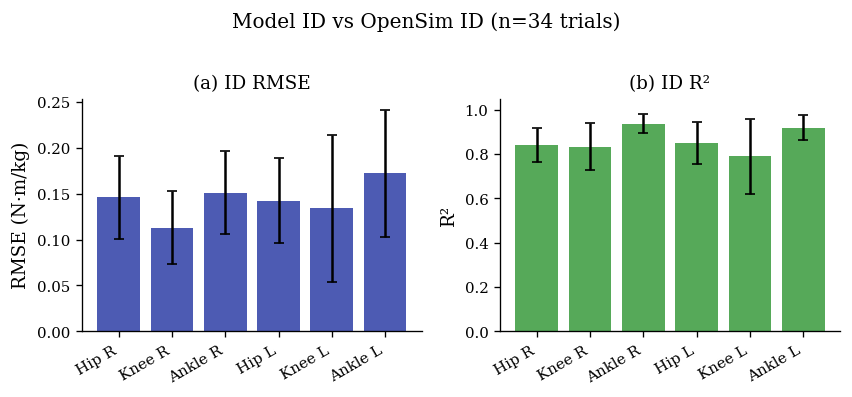

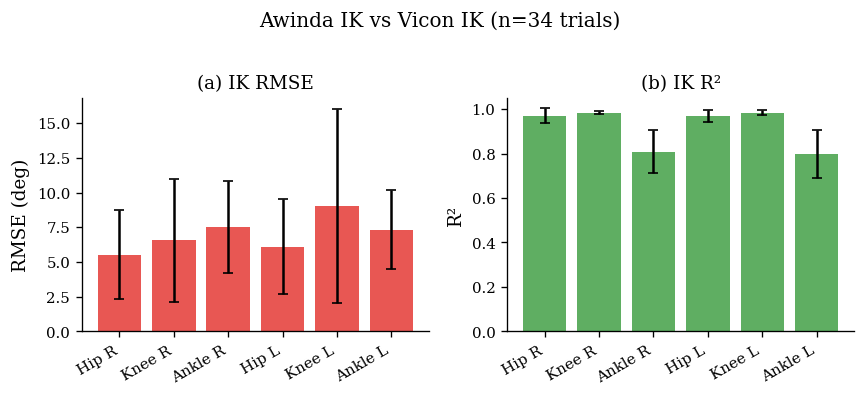

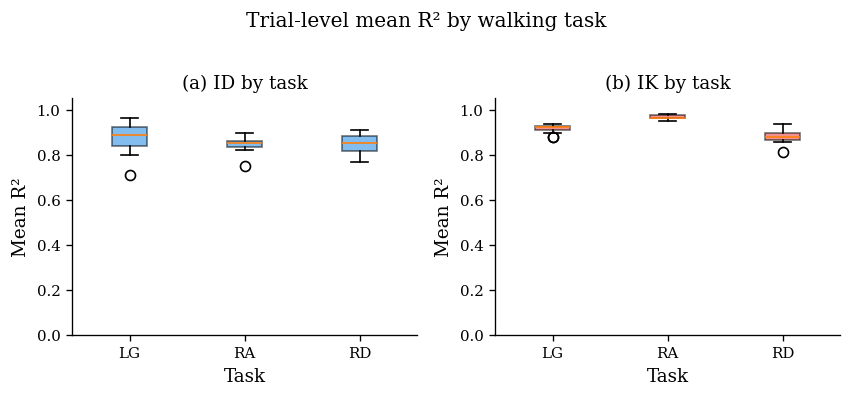

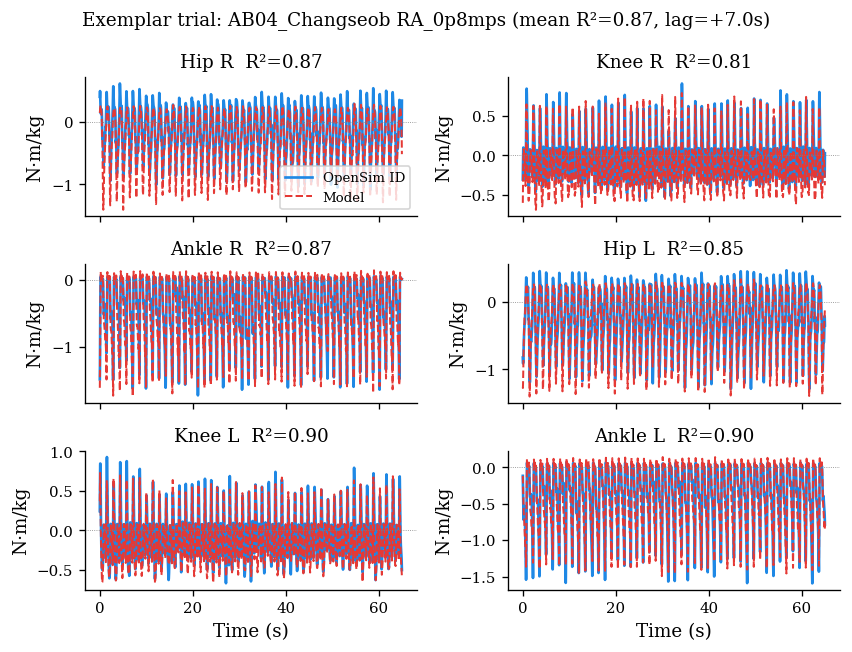


Saved files:
  fig1_id_per_joint.pdf
  fig1_id_per_joint.png
  fig2_ik_per_joint.pdf
  fig2_ik_per_joint.png
  fig3_r2_by_task.pdf
  fig3_r2_by_task.png
  fig4_exemplar_id_timeseries.pdf
  fig4_exemplar_id_timeseries.png
  table1_id_per_joint.csv
  table1_id_per_joint.tex
  table2_ik_per_joint.csv
  table2_ik_per_joint.tex
  table3_id_per_trial.csv
  table3_id_per_trial.tex
  table4_ik_per_trial.csv
  table4_ik_per_trial.tex
  table5_combined_per_trial.csv
  table5_combined_per_trial.tex
  table6_overall_summary.csv
  table6_overall_summary.tex

Table 6 — Overall summary (34 trials, all joint observations):


,metric,unit,rmse_mean_std,r2_mean_std,rmse_overall,r2_overall,n_observations
0,ID (model vs OpenSim),N·m/kg / R²,0.143 ± 0.058,0.862 ± 0.111,0.1547,0.8790,204
1,IK (Awinda vs Vicon),deg / R²,7.013 ± 4.381,0.919 ± 0.102,8.2834,0.8965,204


  ID  (model vs OpenSim): RMSE overall=0.1547 N·m/kg | R² overall=0.8790 | segment R²=0.862 ± 0.111 (n=204)
  IK  (Awinda vs Vicon):  RMSE overall=8.283 deg | R² overall=0.8965 | segment R²=0.919 ± 0.102 (n=204)


In [6]:
# --- Paper-ready tables & figures (run after cells 2–3) ---
if not TRIAL_DATA or detail_df.empty:
    raise RuntimeError('Run the cache load cell (cell 2) first.')
if 'ik_detail_df' not in globals() or ik_detail_df.empty:
    raise RuntimeError('Run the IK comparison cell (cell 3) first.')

# Temporary exclusions (remove or edit before final submission)
PAPER_EXCLUDE_SUBJECTS = {'AB02_Oscar'}
PAPER_EXCLUDE_TRIALS = {'AB05_Maria::LG_0p8mps'}


def _paper_exclude_trial(trial_key: str) -> bool:
    subject, _ = trial_key.split('::', 1)
    return subject in PAPER_EXCLUDE_SUBJECTS or trial_key in PAPER_EXCLUDE_TRIALS


def _filter_paper_trials(df, trial_col='trial'):
    keep = ~df[trial_col].map(_paper_exclude_trial)
    return df.loc[keep].copy()


_paper_trial_keys = sorted(k for k in TRIAL_DATA if not _paper_exclude_trial(k))
_excluded = sorted(k for k in TRIAL_DATA if _paper_exclude_trial(k))
print(f'Paper subset: {len(_paper_trial_keys)} trials (excluded {len(_excluded)})')
if _excluded:
    print('  Excluded: ' + ', '.join(t.replace('::', ' / ') for t in _excluded))

detail_df_paper = _filter_paper_trials(detail_df)
ik_detail_df_paper = _filter_paper_trials(ik_detail_df)
summary_df_paper = _filter_paper_trials(summary_df)
ik_summary_df_paper = _filter_paper_trials(ik_summary_df)

OUT_DIR = PROJECT_ROOT / 'analysis' / 'paper_outputs' / 'awinda'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SYNC_METHOD = next(iter(TRIAL_DATA.values())).get('sync_method', 'angle_xcorr')
TRIM_SEC = float(TRANSIENT_TRIM_SEC) if 'TRANSIENT_TRIM_SEC' in globals() else 15.0

JOINT_LABELS = {
    'hip_flexion_r': 'Hip R', 'knee_angle_r': 'Knee R', 'ankle_angle_r': 'Ankle R',
    'hip_flexion_l': 'Hip L', 'knee_angle_l': 'Knee L', 'ankle_angle_l': 'Ankle L',
}
JOINT_ORDER = list(CHANNELS)

PAPER_RC = {
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
}
PALETTE = {'ID': '#1e88e5', 'IK': '#e53935', 'RMSE': '#3949ab', 'R2': '#43a047'}


def _parse_condition(condition: str):
    task, speed = condition.split('_', 1)
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return task, speed_mps


def _mean_std(series, decimals=3):
    x = np.asarray(series, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return '—'
    return f'{np.mean(x):.{decimals}f} ± {np.std(x, ddof=1):.{decimals}f}'




def _pooled_rmse_r2(y_pred: np.ndarray, y_ref: np.ndarray):
    """Single RMSE / R² over all pooled samples (same R² definition as process_awinda)."""
    pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(y_ref, dtype=np.float64).reshape(-1)
    m = np.isfinite(pred) & np.isfinite(ref)
    if m.sum() < 2:
        return np.nan, np.nan
    err = pred[m] - ref[m]
    rmse = float(np.sqrt(np.mean(err ** 2)))
    r2 = float(np.corrcoef(pred[m], ref[m])[0, 1] ** 2)
    return rmse, r2


def _pooled_id_metrics(trial_keys):
    preds, refs = [], []
    for tk in trial_keys:
        if tk not in TRIAL_DATA:
            continue
        d = TRIAL_DATA[tk]
        preds.append(np.asarray(d['pred_nmpkg'], dtype=np.float64).reshape(-1))
        refs.append(np.asarray(d['id_nmpkg'], dtype=np.float64).reshape(-1))
    if not preds:
        return np.nan, np.nan
    return _pooled_rmse_r2(np.concatenate(preds), np.concatenate(refs))


def _pooled_ik_metrics(trial_keys):
    preds, refs = [], []
    for tk in trial_keys:
        if tk not in IK_TRIAL_DATA:
            continue
        d = IK_TRIAL_DATA[tk]
        preds.append(np.asarray(d['awinda_deg'], dtype=np.float64).reshape(-1))
        refs.append(np.asarray(d['vicon_deg'], dtype=np.float64).reshape(-1))
    if not preds:
        return np.nan, np.nan
    return _pooled_rmse_r2(np.concatenate(preds), np.concatenate(refs))


def _attach_trial_meta(df, trial_col='trial'):
    df = df.copy()
    meta = df[trial_col].str.split('::', n=1, expand=True)
    df['subject'] = meta[0]
    df['condition'] = meta[1]
    parsed = df['condition'].apply(_parse_condition)
    df['task'] = [p[0] for p in parsed]
    df['speed_mps'] = [p[1] for p in parsed]
    return df


def _joint_summary(detail, value_col, r2_col):
    rows = []
    for ch in JOINT_ORDER:
        sub = detail[detail['channel'] == ch]
        rows.append({
            'joint': JOINT_LABELS[ch],
            'channel': ch,
            'n_trials': sub['trial'].nunique(),
            f'{value_col}_mean_std': _mean_std(sub[value_col]),
            f'{r2_col}_mean_std': _mean_std(sub[r2_col]),
            f'{value_col}_mean': float(sub[value_col].mean()),
            f'{value_col}_std': float(sub[value_col].std(ddof=1)),
            f'{r2_col}_mean': float(sub[r2_col].mean()),
            f'{r2_col}_std': float(sub[r2_col].std(ddof=1)),
        })
    return pd.DataFrame(rows)


def _save_table(df, stem, caption=''):
    csv_path = OUT_DIR / f'{stem}.csv'
    tex_path = OUT_DIR / f'{stem}.tex'
    df.to_csv(csv_path, index=False)
    tex = df.to_latex(index=False, escape=True, caption=caption, label=f'tab:{stem}')
    tex_path.write_text(tex)
    return csv_path, tex_path


# --- Tables ---
id_detail = _attach_trial_meta(detail_df_paper)
ik_detail = _attach_trial_meta(ik_detail_df_paper)

table_id_joint = _joint_summary(id_detail, 'rmse_nmpkg', 'r2_nmpkg')
table_id_joint_display = table_id_joint[[
    'joint', 'n_trials', 'rmse_nmpkg_mean_std', 'r2_nmpkg_mean_std',
]]

table_ik_joint = _joint_summary(ik_detail, 'rmse_deg', 'r2')
table_ik_joint_display = table_ik_joint[[
    'joint', 'n_trials', 'rmse_deg_mean_std', 'r2_mean_std',
]]

id_trial = _attach_trial_meta(summary_df_paper.copy())
id_trial['lag_s'] = id_trial['trial'].map(lambda k: TRIAL_DATA[k]['lag_seconds'])
id_trial = id_trial[[
    'trial', 'subject', 'condition', 'task', 'speed_mps', 'n', 'mean_rmse', 'mean_r2', 'lag_s',
]].sort_values(['subject', 'task', 'speed_mps'])
id_trial = id_trial.rename(columns={
    'mean_rmse': 'mean_rmse_nmpkg', 'mean_r2': 'mean_r2_id', 'n': 'n_samples',
})

ik_trial = _attach_trial_meta(ik_summary_df_paper.copy())
ik_trial = ik_trial[[
    'trial', 'subject', 'condition', 'task', 'speed_mps', 'n', 'mean_rmse_deg', 'mean_r2',
]].sort_values(['subject', 'task', 'speed_mps'])
ik_trial = ik_trial.rename(columns={'mean_r2': 'mean_r2_ik', 'n': 'n_samples'})

combined_trial = id_trial.merge(
    ik_trial[['trial', 'mean_rmse_deg', 'mean_r2_ik']], on='trial', how='left',
).drop(columns=['trial'])

_id_rmse_overall, _id_r2_overall = _pooled_id_metrics(_paper_trial_keys)
_ik_rmse_overall, _ik_r2_overall = _pooled_ik_metrics(_paper_trial_keys)

overall_rows = pd.DataFrame([
    {
        'metric': 'ID (model vs OpenSim)',
        'unit': 'N·m/kg / R²',
        'rmse_mean_std': _mean_std(id_detail['rmse_nmpkg']),
        'r2_mean_std': _mean_std(id_detail['r2_nmpkg']),
        'rmse_overall': round(_id_rmse_overall, 4),
        'r2_overall': round(_id_r2_overall, 4),
        'n_observations': len(id_detail),
    },
    {
        'metric': 'IK (Awinda vs Vicon)',
        'unit': 'deg / R²',
        'rmse_mean_std': _mean_std(ik_detail['rmse_deg']),
        'r2_mean_std': _mean_std(ik_detail['r2']),
        'rmse_overall': round(_ik_rmse_overall, 4),
        'r2_overall': round(_ik_r2_overall, 4),
        'n_observations': len(ik_detail),
    },
])

for stem, df, cap in [
    ('table1_id_per_joint', table_id_joint_display, f'Model ID vs OpenSim per joint (sync={SYNC_METHOD}, {TRIM_SEC:.0f}s trim).'),
    ('table2_ik_per_joint', table_ik_joint_display, f'Awinda vs Vicon IK per joint ({TRIM_SEC:.0f}s post-sync trim).'),
    ('table3_id_per_trial', id_trial.drop(columns=['trial']).round(4), 'Per-trial ID summary.'),
    ('table4_ik_per_trial', ik_trial.drop(columns=['trial']).round(4), 'Per-trial IK summary.'),
    ('table5_combined_per_trial', combined_trial.round(4), 'Per-trial ID and IK summary.'),
    ('table6_overall_summary', overall_rows, 'Overall summary across all joint-trial observations.'),
]:
    _save_table(df, stem, caption=cap)

print(f'Paper outputs → {OUT_DIR}')
print(f'  Sync: {SYNC_METHOD} | post-sync trim: {TRIM_SEC:.0f} s | trials: {len(_paper_trial_keys)}')
print('\nTable 1 — Model ID vs OpenSim (per joint, mean ± SD across trials):')
display(table_id_joint_display)
print('\nTable 2 — Awinda IK vs Vicon (per joint, mean ± SD across trials):')
display(table_ik_joint_display)
# --- Figures ---
x = np.arange(len(JOINT_ORDER))
labels = [JOINT_LABELS[c] for c in JOINT_ORDER]
task_order = ['LG', 'RA', 'RD']

with plt.rc_context(PAPER_RC):

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharex=True)
    axes[0].bar(x, table_id_joint['rmse_nmpkg_mean'], yerr=table_id_joint['rmse_nmpkg_std'],
                color=PALETTE['RMSE'], capsize=3, alpha=0.9)
    axes[0].set_ylabel('RMSE (N·m/kg)')
    axes[0].set_title('(a) ID RMSE')
    axes[1].bar(x, table_id_joint['r2_nmpkg_mean'], yerr=table_id_joint['r2_nmpkg_std'],
                color=PALETTE['R2'], capsize=3, alpha=0.9)
    axes[1].set_ylabel('R²')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('(b) ID R²')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right')
    fig.suptitle(f'Model ID vs OpenSim ID (n={len(_paper_trial_keys)} trials)', y=1.02, fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig1_id_per_joint.pdf')
    fig.savefig(OUT_DIR / 'fig1_id_per_joint.png')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharex=True)
    axes[0].bar(x, table_ik_joint['rmse_deg_mean'], yerr=table_ik_joint['rmse_deg_std'],
                color=PALETTE['IK'], capsize=3, alpha=0.85)
    axes[0].set_ylabel('RMSE (deg)')
    axes[0].set_title('(a) IK RMSE')
    axes[1].bar(x, table_ik_joint['r2_mean'], yerr=table_ik_joint['r2_std'],
                color=PALETTE['R2'], capsize=3, alpha=0.85)
    axes[1].set_ylabel('R²')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('(b) IK R²')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right')
    fig.suptitle(f'Awinda IK vs Vicon IK (n={len(_paper_trial_keys)} trials)', y=1.02, fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig2_ik_per_joint.pdf')
    fig.savefig(OUT_DIR / 'fig2_ik_per_joint.png')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
    id_groups = [id_trial.loc[id_trial['task'] == t, 'mean_r2_id'].to_numpy() for t in task_order]
    ik_groups = [ik_trial.loc[ik_trial['task'] == t, 'mean_r2_ik'].to_numpy() for t in task_order]
    bp1 = axes[0].boxplot(id_groups, tick_labels=task_order, patch_artist=True)
    for box in bp1['boxes']:
        box.set(facecolor=PALETTE['ID'], alpha=0.55)
    axes[0].set_ylabel('Mean R²')
    axes[0].set_xlabel('Task')
    axes[0].set_title('(a) ID by task')
    axes[0].set_ylim(0, 1.05)
    bp2 = axes[1].boxplot(ik_groups, tick_labels=task_order, patch_artist=True)
    for box in bp2['boxes']:
        box.set(facecolor=PALETTE['IK'], alpha=0.55)
    axes[1].set_ylabel('Mean R²')
    axes[1].set_xlabel('Task')
    axes[1].set_title('(b) IK by task')
    axes[1].set_ylim(0, 1.05)
    fig.suptitle('Trial-level mean R² by walking task', y=1.02, fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig3_r2_by_task.pdf')
    fig.savefig(OUT_DIR / 'fig3_r2_by_task.png')
    plt.show()

    # Exemplar: trial closest to median ID R²
    ex_row = id_trial.iloc[(id_trial['mean_r2_id'] - id_trial['mean_r2_id'].median()).abs().argsort().iloc[0]]
    ex_key = ex_row['trial']
    d = TRIAL_DATA[ex_key]
    t = np.asarray(d['t'], dtype=np.float64)
    t = t - t[0]
    y_pred = np.asarray(d['pred_nmpkg'], dtype=np.float64)
    y_id = np.asarray(d['id_nmpkg'], dtype=np.float64)
    fig, axs = plt.subplots(3, 2, figsize=(7.2, 5.5), sharex=True)
    for c, ax in enumerate(axs.reshape(-1)):
        m = d['metrics'][c]
        ax.plot(t, y_id[:, c], color=PALETTE['ID'], lw=1.6, label='OpenSim ID')
        ax.plot(t, y_pred[:, c], color=PALETTE['IK'], lw=1.2, ls='--', label='Model')
        ax.set_title(f"{JOINT_LABELS[CHANNELS[c]]}  R²={m['r2_nmpkg']:.2f}")
        ax.set_ylabel('N·m/kg')
        ax.axhline(0, color='gray', lw=0.5, ls=':')
        if c == 0:
            ax.legend(fontsize=8)
    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time (s)')
    fig.suptitle(
        f'Exemplar trial: {ex_row["subject"]} {ex_row["condition"]} '
        f'(mean R²={ex_row["mean_r2_id"]:.2f}, lag={ex_row["lag_s"]:+.1f}s)',
        fontsize=11,
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig4_exemplar_id_timeseries.pdf')
    fig.savefig(OUT_DIR / 'fig4_exemplar_id_timeseries.png')
    plt.show()

print('\nSaved files:')
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name}')

print(f'\nTable 6 — Overall summary ({len(_paper_trial_keys)} trials, all joint observations):')
display(overall_rows)

print(
    f"  ID  (model vs OpenSim): RMSE overall={_id_rmse_overall:.4f} N·m/kg | "
    f"R² overall={_id_r2_overall:.4f} | segment R²={_mean_std(id_detail['r2_nmpkg'])} (n={len(id_detail)})"
)
print(
    f"  IK  (Awinda vs Vicon):  RMSE overall={_ik_rmse_overall:.3f} deg | "
    f"R² overall={_ik_r2_overall:.4f} | segment R²={_mean_std(ik_detail['r2'])} (n={len(ik_detail)})"
)
